In [22]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY") # type: ignore
llm=ChatOpenAI(model="gpt-4o-mini")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3282593d8d', 'id': 'chatcmpl-DkoiyLZKXBeAFsDS8OFG6jwZrlb4z', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7346-42e0-7152-af04-19f8c06ab13b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [23]:
from typing_extensions import Literal,TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
import operator

class Section(BaseModel):
    name:str=Field(description="Name for this section of the report")
    description:str=Field(description="Brief Overview of he main topics and concepts of the section")

class Sections(BaseModel):
    sections:list[Section]=Field(description="Senctions of the report")

planner=llm.with_structured_output(Sections)

### Creating works Dynamically in LangGraph

In [24]:
from langgraph.types import Send
from typing import Annotated

class State(TypedDict):
    topic:str
    sections:list[Section]
    completed_sections:Annotated[list,operator.add]
    final_report:str

class WorkerState(TypedDict):
    section:Section
    completed_sections:Annotated[list,operator.add]

In [25]:
def orchestrator(state:State):
    """Orchestrator the generates a plan for the report"""

    report_sections=planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report"),
            HumanMessage(content=f"Here is the report topic : {state['topic']}"),
        ]
    )

    print("Report Sections :", report_sections)
    return {"sections":report_sections.sections}

def llm_call(state:WorkerState):
    """Worker writes a section of the report"""

    section= llm.invoke(
        [
            SystemMessage(content="Write a report section following the provided name and description."),
            HumanMessage(content=f"Here is the section name : {state['section'].name} and description: {state['section'].description}"),
        ]
    )

    return {"completed_section": [section.content]}

def assign_workers(state:State):
    """Assign a worker to each section in the plan"""
    return [Send("llm_call",{"section":s}) for s in state["sections"]]

def synthesizer(state:State):
    """Synthesize full report from sections"""

    completed_sections = state["completed_sections"]
    completed_report_sections= "\n\n---\n\n".join(completed_sections)

    return {"final_report":completed_report_sections}

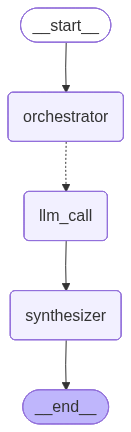

In [26]:
orchestrator_worker_builder= StateGraph(State)

orchestrator_worker_builder.add_node("orchestrator",orchestrator)
orchestrator_worker_builder.add_node("llm_call",llm_call)
orchestrator_worker_builder.add_node("synthesizer",synthesizer)

orchestrator_worker_builder.add_edge(START,"orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator",assign_workers,["llm_call"]
)

orchestrator_worker_builder.add_edge("llm_call","synthesizer")
orchestrator_worker_builder.add_edge("synthesizer",END)


compiled_graph = orchestrator_worker_builder.compile()
display(Image(compiled_graph.get_graph().draw_mermaid_png()))


In [ ]:


state= compiled_graph.invoke({"topic":"Create a report on Agentic AI RAGs"})


from IPython.display import Markdown
Markdown(state['final_report'])

Report Sections : sections=[Section(name='Introduction to Agentic AI RAGs', description='This section will provide an overview of Agentic AI, defining what it is and its relevance in AI applications. It will also introduce RAGs (Retrieval-Augmented Generation) and discuss their importance in enhancing AI capabilities.'), Section(name='The Evolution of Agentic AI', description='This section will trace the development of Agentic AI, highlighting key milestones, breakthroughs, and technological advancements that have led to the emergence of RAGs.'), Section(name='Understanding Retrieval-Augmented Generation (RAG)', description='This section will explain the concept of RAGs in detail, including how they work, their architecture, and their role in improving the performance of AI models in tasks such as natural language processing and information retrieval.'), Section(name='Applications of Agentic AI RAGs', description='This section will explore the various practical applications of Agentic 